# HyDMIS — NewsPolyML EDA
## European Multilingual Disinformation Domain

**Dataset:** NewsPolyML v2 — 32,129 European multilingual news claims (Mohtaj et al., 2024)
**Languages:** EN (38.3%), ES (31.2%), IT (11.3%), DE (10.3%), FR (8.8%)
**Key finding:** Italian anomaly — pagellapolitica false=16.7% vs AFP false=78.3% — publisher-driven label bias
**Purpose:** HyDMIS European multilingual disinformation evaluation benchmark

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from newspolyml_loader import load_newspolyml

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)
LANG_NAMES = {'en': 'English', 'es': 'Spanish', 'it': 'Italian', 'de': 'German', 'fr': 'French'}
LANG_COLORS = {'en': 'steelblue', 'es': 'coral', 'it': '#5cb85c', 'de': '#f0ad4e', 'fr': '#9b59b6'}
LABEL_COLORS = {'false': '#e74c3c', 'mixture': '#f39c12', 'true': '#2ecc71', 'mislabeled': '#95a5a6', 'other': '#bdc3c7'}
print('Imports complete')

Imports complete


In [2]:
result = load_newspolyml(data_dir='../data/raw')
df = result['data'].copy()
df['body_len'] = df['article_body'].astype(str).str.len()
df['body_words'] = df['article_body'].astype(str).str.split().str.len()
df['claim_date'] = pd.to_datetime(df['claim_publication_date'], errors='coerce')
df['year'] = df['claim_date'].dt.year
print(f'Shape: {df.shape}')
print(f'Total records: {len(df):,}')
print(df['normalized_label'].value_counts())

Loading NewsPolyML...


  ✓ NewsPolyML: 32,129 records | News | EN/DE/ES/FR/IT


Shape: (32129, 29)
Total records: 32,129
normalized_label
false         22944
mixture        6151
true           2476
mislabeled      309
other           249
Name: count, dtype: int64


## 1. Label Distribution — False Dominates (71.4%)

false=71.4%, mixture=19.1%, true=7.7%. Severe class imbalance.
HyDMIS binary: false+mislabeled=disinformation, true=credible, mixture=ambiguous.

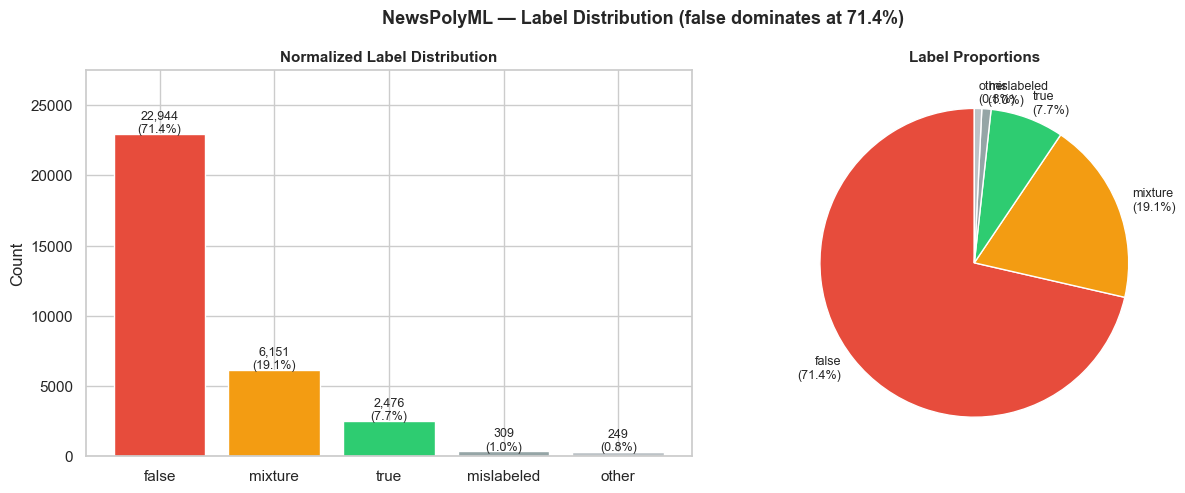

Fig 1 saved — newspolyml_label_distribution.png


In [3]:
label_counts = df['normalized_label'].value_counts()
labels = label_counts.index.tolist()
counts = label_counts.values
colors = [LABEL_COLORS.get(l, '#cccccc') for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=9)
axes[0].set_title('Normalized Label Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, counts.max()*1.2)

axes[1].pie(counts, labels=[f'{l}\n({v/len(df):.1%})' for l,v in zip(labels,counts)],
            colors=colors, startangle=90, textprops={'fontsize':9})
axes[1].set_title('Label Proportions', fontsize=11, fontweight='bold')

plt.suptitle('NewsPolyML — Label Distribution (false dominates at 71.4%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 1 saved — newspolyml_label_distribution.png')

## 2. Language Distribution — EN + ES = 69.5%

English (38.3%) and Spanish (31.2%) dominate. French (8.8%) smallest.

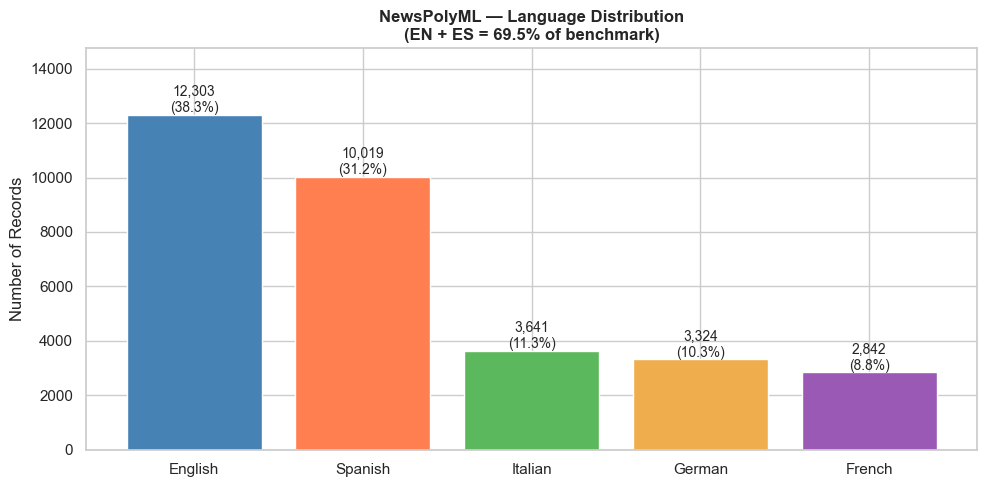

Fig 2 saved — newspolyml_language_distribution.png


In [4]:
lang_counts = df['article_language'].value_counts()
langs = lang_counts.index.tolist()
colors_lang = [LANG_COLORS.get(l, '#cccccc') for l in langs]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([LANG_NAMES.get(l,l) for l in langs], lang_counts.values,
              color=colors_lang, edgecolor='white')
for bar, val, lang in zip(bars, lang_counts.values, langs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
ax.set_title('NewsPolyML — Language Distribution\n(EN + ES = 69.5% of benchmark)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Records'); ax.set_ylim(0, lang_counts.max()*1.2)
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_language_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 2 saved — newspolyml_language_distribution.png')

## 3. Publisher Distribution — AFP Dominates (57.9%)

AFP (57.9%) single publisher dominance. May bias cross-publisher evaluation.

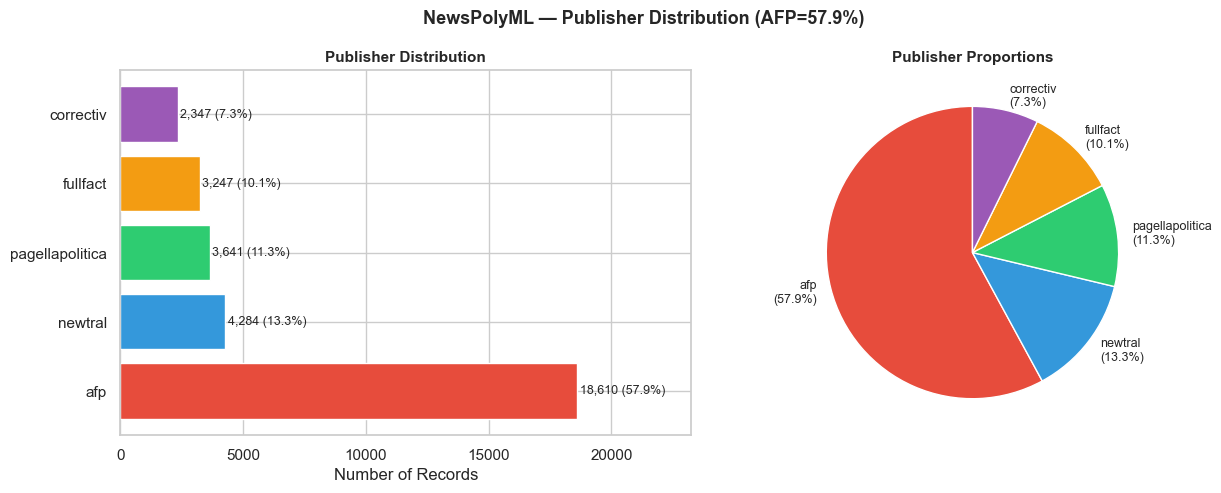

Fig 3 saved — newspolyml_publisher_distribution.png


In [5]:
pub_counts = df['article_publisher_name'].value_counts()
pub_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].barh(pub_counts.index, pub_counts.values, color=pub_colors, edgecolor='white')
for bar, val in zip(bars, pub_counts.values):
    axes[0].text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
                 f'{val:,} ({val/len(df):.1%})', va='center', fontsize=9)
axes[0].set_title('Publisher Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Number of Records'); axes[0].set_xlim(0, pub_counts.max()*1.25)

axes[1].pie(pub_counts.values, labels=[f'{p}\n({v/len(df):.1%})' for p,v in pub_counts.items()],
            colors=pub_colors, startangle=90, textprops={'fontsize':9})
axes[1].set_title('Publisher Proportions', fontsize=11, fontweight='bold')

plt.suptitle('NewsPolyML — Publisher Distribution (AFP=57.9%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_publisher_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 3 saved — newspolyml_publisher_distribution.png')

## 4. Label by Language — Italian Anomaly

IT: false=16.7%, true=41.6% — completely different from EN/ES/DE/FR (all ~77-79% false).
Italian anomaly is publisher-driven — pagellapolitica uses different rating scale.

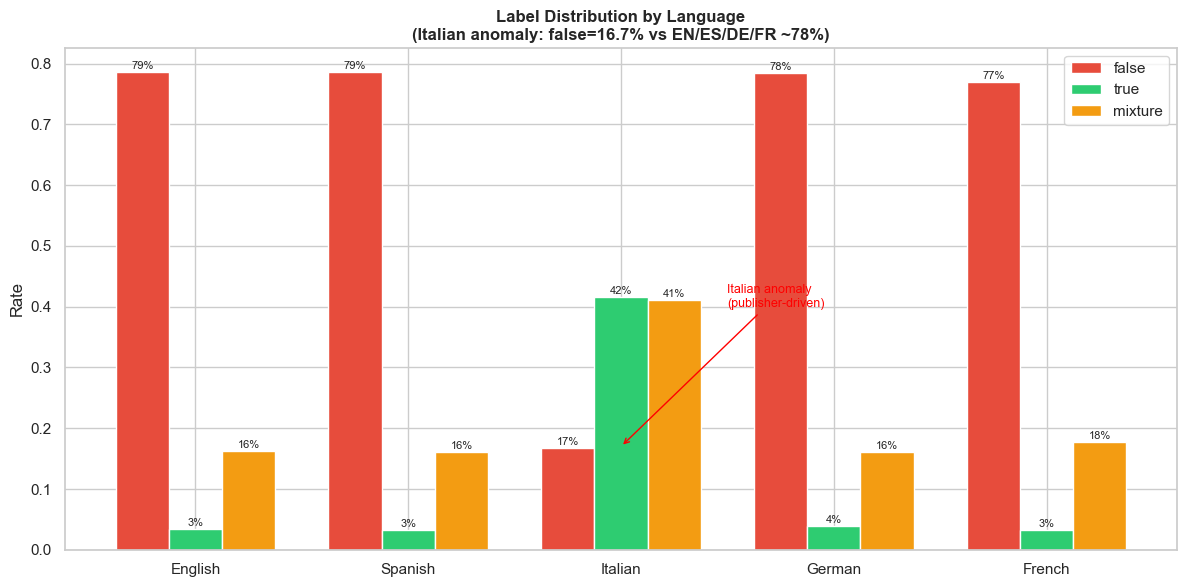

Fig 4 saved — newspolyml_label_by_language.png


In [6]:
langs_order = ['en','es','it','de','fr']
false_rates = [df[df['article_language']==l]['normalized_label'].eq('false').mean() for l in langs_order]
true_rates = [df[df['article_language']==l]['normalized_label'].eq('true').mean() for l in langs_order]
mix_rates = [df[df['article_language']==l]['normalized_label'].eq('mixture').mean() for l in langs_order]
lang_labels = [LANG_NAMES[l] for l in langs_order]
x = np.arange(len(langs_order)); width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x-width, false_rates, width, color='#e74c3c', label='false', edgecolor='white')
bars2 = ax.bar(x, true_rates, width, color='#2ecc71', label='true', edgecolor='white')
bars3 = ax.bar(x+width, mix_rates, width, color='#f39c12', label='mixture', edgecolor='white')

for bar, val in zip(bars1, false_rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=8)
for bar, val in zip(bars2, true_rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=8)
for bar, val in zip(bars3, mix_rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(lang_labels)
ax.set_title('Label Distribution by Language\n(Italian anomaly: false=16.7% vs EN/ES/DE/FR ~78%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Rate'); ax.legend()
ax.annotate('Italian anomaly\n(publisher-driven)', xy=(2, 0.17), xytext=(2.5, 0.4),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_label_by_language.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 4 saved — newspolyml_label_by_language.png')

## 5. LLaMA vs Normalized Label Agreement — 65.4%

34.6% disagreement. LLaMA overestimates false (78.7% vs 71.4%), underestimates mixture.

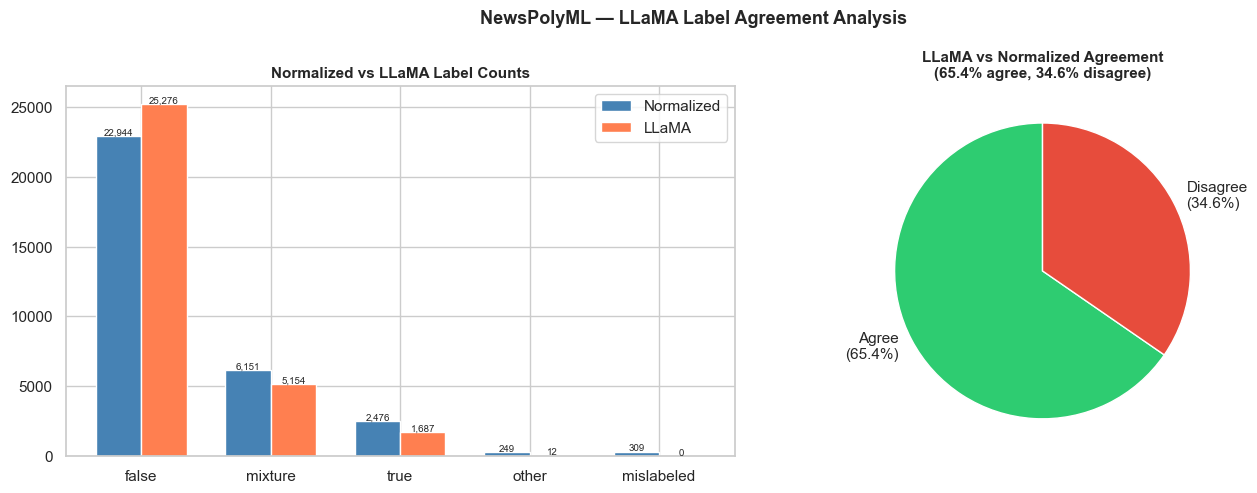

Fig 5 saved — newspolyml_llama_agreement.png


In [7]:
norm_counts = df['normalized_label'].value_counts()
llama_counts = df['llama_label'].value_counts()
all_labels = ['false', 'mixture', 'true', 'other', 'mislabeled']
norm_vals = [norm_counts.get(l, 0) for l in all_labels]
llama_vals = [llama_counts.get(l, 0) for l in all_labels]
x = np.arange(len(all_labels)); width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars1 = axes[0].bar(x-width/2, norm_vals, width, color='steelblue', label='Normalized', edgecolor='white')
bars2 = axes[0].bar(x+width/2, llama_vals, width, color='coral', label='LLaMA', edgecolor='white')
for bar, val in zip(bars1, norm_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,}', ha='center', fontsize=7)
for bar, val in zip(bars2, llama_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,}', ha='center', fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(all_labels)
axes[0].set_title('Normalized vs LLaMA Label Counts', fontsize=11, fontweight='bold')
axes[0].legend()

agree = (df['normalized_label'] == df['llama_label']).sum()
disagree = len(df) - agree
axes[1].pie([agree, disagree], labels=[f'Agree\n({agree/len(df):.1%})', f'Disagree\n({disagree/len(df):.1%})'],
            colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize':11})
axes[1].set_title('LLaMA vs Normalized Agreement\n(65.4% agree, 34.6% disagree)', fontsize=11, fontweight='bold')

plt.suptitle('NewsPolyML — LLaMA Label Agreement Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_llama_agreement.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 5 saved — newspolyml_llama_agreement.png')

## 6. LLaMA Confidence Distribution — 83.6% Confidence=5

LLaMA highly confident (mean=4.83) but wrong 34.6% of the time.
High confidence + high disagreement = overconfident model on mixture class.

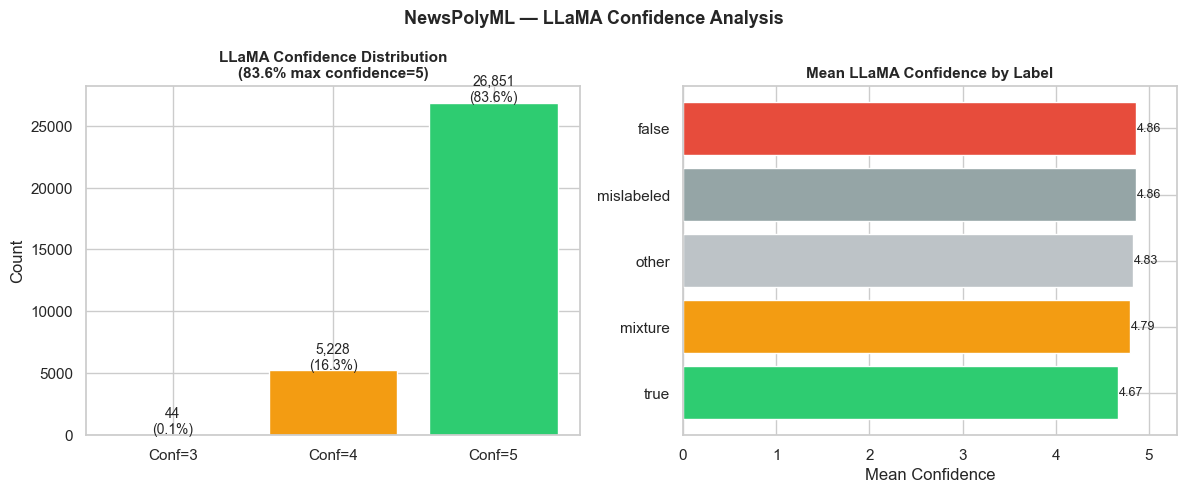

Fig 6 saved — newspolyml_llama_confidence.png


In [8]:
conf_counts = df['llama_confidence'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar([f'Conf={c:.0f}' for c in conf_counts.index], conf_counts.values,
                    color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
for bar, val in zip(bars, conf_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('LLaMA Confidence Distribution\n(83.6% max confidence=5)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')

conf_by_label = df.groupby('normalized_label')['llama_confidence'].mean().sort_values()
axes[1].barh(conf_by_label.index, conf_by_label.values,
             color=[LABEL_COLORS.get(l,'#cccccc') for l in conf_by_label.index], edgecolor='white')
for i, (label, val) in enumerate(conf_by_label.items()):
    axes[1].text(val+0.01, i, f'{val:.2f}', va='center', fontsize=9)
axes[1].set_title('Mean LLaMA Confidence by Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Confidence'); axes[1].set_xlim(0, 5.3)

plt.suptitle('NewsPolyML — LLaMA Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_llama_confidence.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 6 saved — newspolyml_llama_confidence.png')

## 6b. LLaMA Confidence by Language — Italian Only 54.1% Max Confidence

Italian conf=5: 54.1% vs Spanish 91.6% — LLaMA uncertain on Italian mixture-heavy claims.
Confirms publisher-driven label ambiguity in pagellapolitica dataset.

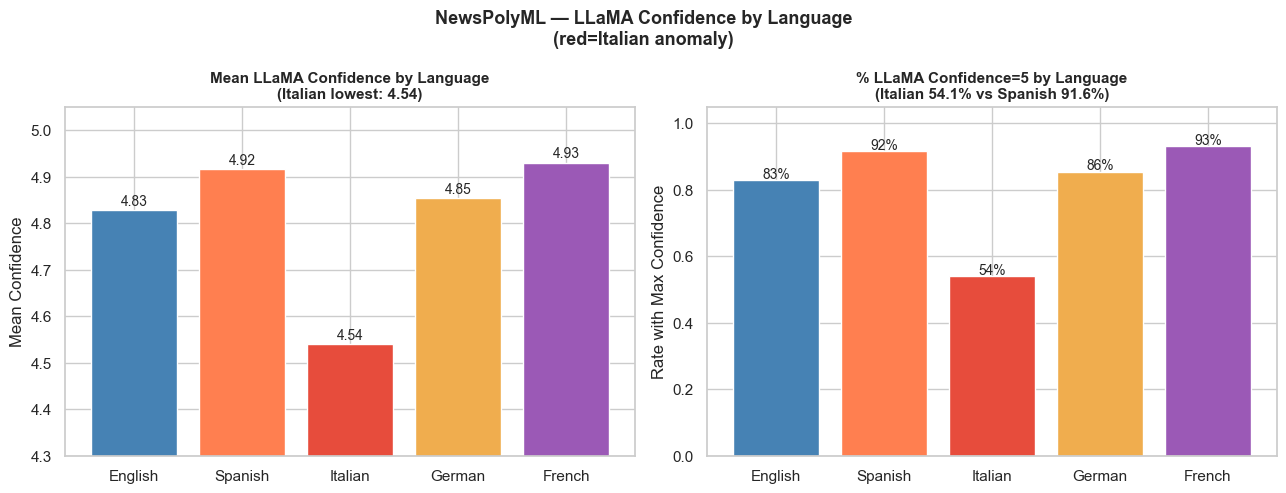

Fig 6b saved — newspolyml_confidence_by_language.png


In [9]:
langs_order = ['en','es','it','de','fr']
lang_labels = [LANG_NAMES[l] for l in langs_order]
mean_confs = [df[df['article_language']==l]['llama_confidence'].mean() for l in langs_order]
high_confs = [df[df['article_language']==l]['llama_confidence'].eq(5).mean() for l in langs_order]
colors_conf = ['#e74c3c' if l == 'it' else LANG_COLORS[l] for l in langs_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars1 = axes[0].bar(lang_labels, mean_confs, color=colors_conf, edgecolor='white')
for bar, val in zip(bars1, mean_confs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_title('Mean LLaMA Confidence by Language\n(Italian lowest: 4.54)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Confidence'); axes[0].set_ylim(4.3, 5.05)

bars2 = axes[1].bar(lang_labels, high_confs, color=colors_conf, edgecolor='white')
for bar, val in zip(bars2, high_confs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.0%}', ha='center', fontsize=10)
axes[1].set_title('% LLaMA Confidence=5 by Language\n(Italian 54.1% vs Spanish 91.6%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rate with Max Confidence'); axes[1].set_ylim(0, 1.05)

plt.suptitle('NewsPolyML — LLaMA Confidence by Language\n(red=Italian anomaly)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_confidence_by_language.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 6b saved — newspolyml_confidence_by_language.png')

## 7. Article Sentiment — 93.9% Negative

Fact-check articles overwhelmingly negative framing. Consistent with debunking purpose.

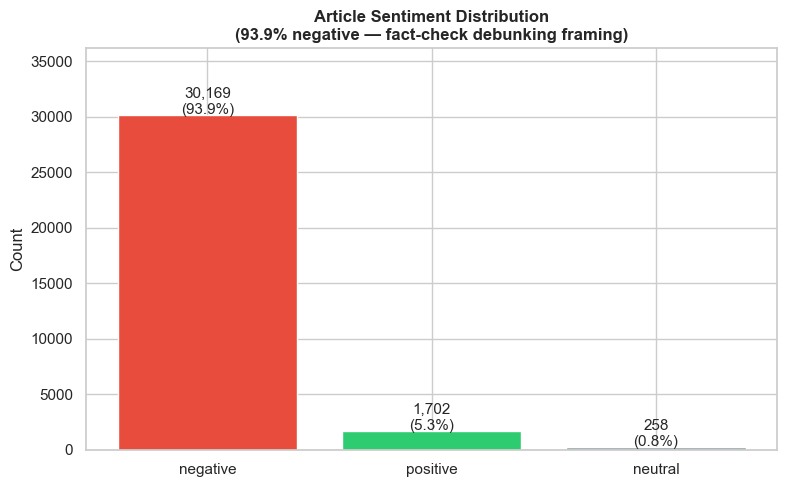

Fig 7 saved — newspolyml_sentiment.png


In [10]:
sent_counts = df['article_sentiment'].value_counts()
sent_colors = {'negative':'#e74c3c', 'positive':'#2ecc71', 'neutral':'#95a5a6'}
colors_sent = [sent_colors.get(s,'#cccccc') for s in sent_counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sent_counts.index, sent_counts.values, color=colors_sent, edgecolor='white')
for bar, val in zip(bars, sent_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
ax.set_title('Article Sentiment Distribution\n(93.9% negative — fact-check debunking framing)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count'); ax.set_ylim(0, sent_counts.max()*1.2)
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_sentiment.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 7 saved — newspolyml_sentiment.png')

## 7b. Article Sentiment by Language — Italian and Spanish More Positive

German 99.4% negative vs Italian 87.1% — publisher framing differs.
Claim review sentiment (58.4% neg) vs article sentiment (93.9% neg) — completely different framing.

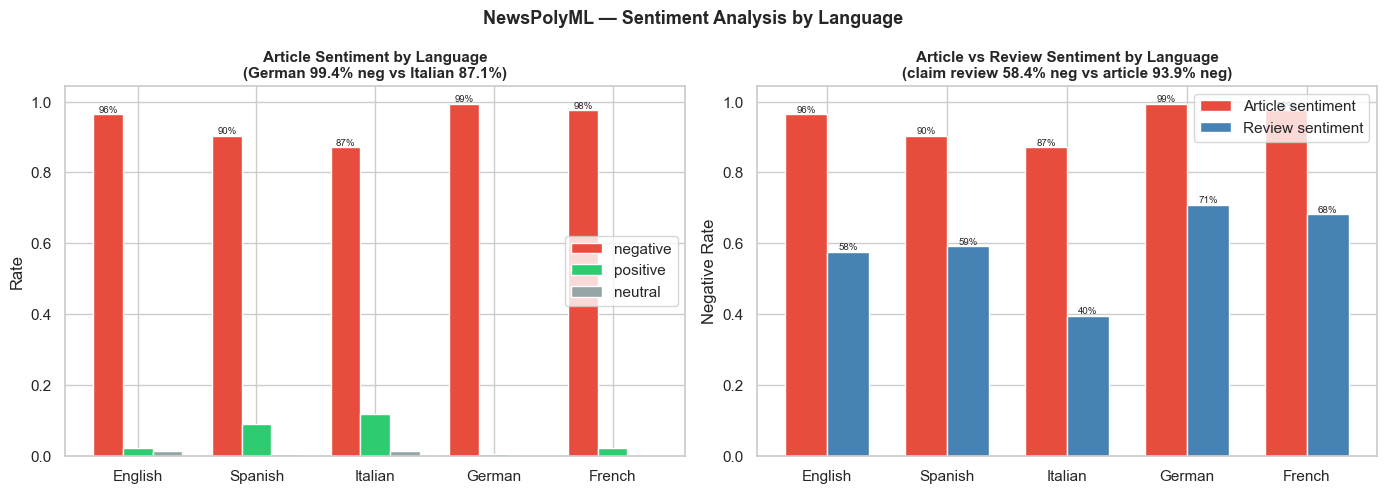

Fig 7b saved — newspolyml_sentiment_by_language.png


In [11]:
langs_order = ['en','es','it','de','fr']
lang_labels = [LANG_NAMES[l] for l in langs_order]
neg_rates = [df[df['article_language']==l]['article_sentiment'].eq('negative').mean() for l in langs_order]
pos_rates = [df[df['article_language']==l]['article_sentiment'].eq('positive').mean() for l in langs_order]
neu_rates = [df[df['article_language']==l]['article_sentiment'].eq('neutral').mean() for l in langs_order]
review_neg = [df[df['article_language']==l]['claim_review_sentiment'].eq('negative').mean() for l in langs_order]
x = np.arange(len(langs_order)); width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars1 = axes[0].bar(x-width, neg_rates, width, color='#e74c3c', label='negative', edgecolor='white')
bars2 = axes[0].bar(x, pos_rates, width, color='#2ecc71', label='positive', edgecolor='white')
bars3 = axes[0].bar(x+width, neu_rates, width, color='#95a5a6', label='neutral', edgecolor='white')
for bar, val in zip(bars1, neg_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(lang_labels)
axes[0].set_title('Article Sentiment by Language\n(German 99.4% neg vs Italian 87.1%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rate'); axes[0].legend()

x2 = np.arange(len(langs_order)); width2 = 0.35
art_neg = neg_rates
rev_neg = review_neg
bars_art = axes[1].bar(x2-width2/2, art_neg, width2, color='#e74c3c', label='Article sentiment', edgecolor='white')
bars_rev = axes[1].bar(x2+width2/2, rev_neg, width2, color='steelblue', label='Review sentiment', edgecolor='white')
for bar, val in zip(bars_art, art_neg):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=7)
for bar, val in zip(bars_rev, rev_neg):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=7)
axes[1].set_xticks(x2); axes[1].set_xticklabels(lang_labels)
axes[1].set_title('Article vs Review Sentiment by Language\n(claim review 58.4% neg vs article 93.9% neg)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Negative Rate'); axes[1].legend()

plt.suptitle('NewsPolyML — Sentiment Analysis by Language', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_sentiment_by_language.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 7b saved — newspolyml_sentiment_by_language.png')

## 8. Article Body Length by Language — French Longest

French mean=6,718 chars (1,059 words). English shortest at 3,275 chars (542 words).
Longer articles = more context for LDA topic modeling.

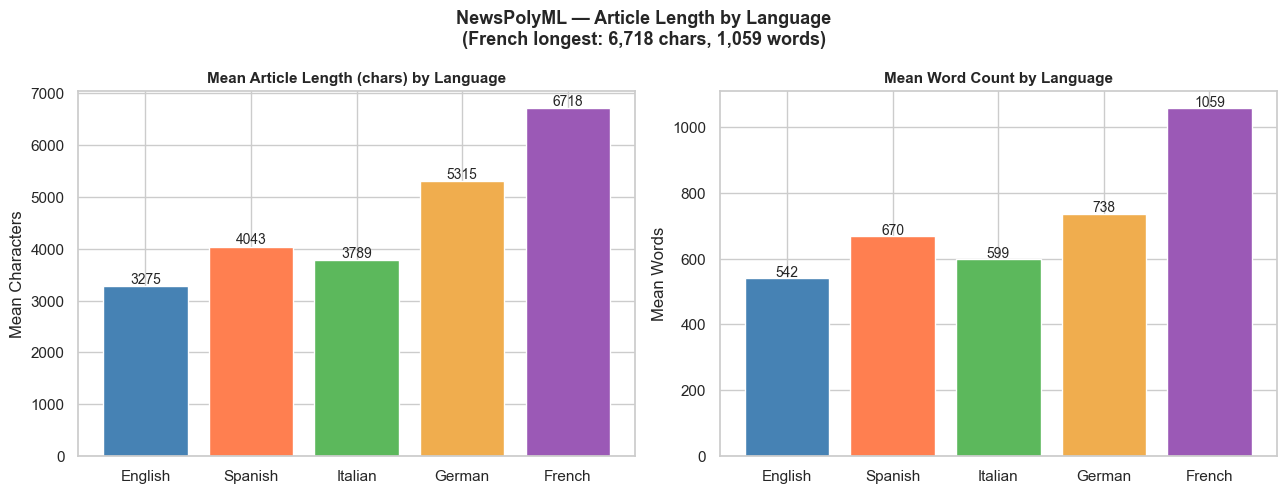

Fig 8 saved — newspolyml_article_length.png


In [12]:
langs_order = ['en','es','it','de','fr']
lang_means_chars = [df[df['article_language']==l]['body_len'].mean() for l in langs_order]
lang_means_words = [df[df['article_language']==l]['body_words'].mean() for l in langs_order]
lang_labels = [LANG_NAMES[l] for l in langs_order]
colors_lang_ordered = [LANG_COLORS[l] for l in langs_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars1 = axes[0].bar(lang_labels, lang_means_chars, color=colors_lang_ordered, edgecolor='white')
for bar, val in zip(bars1, lang_means_chars):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:.0f}', ha='center', fontsize=10)
axes[0].set_title('Mean Article Length (chars) by Language', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Characters')

bars2 = axes[1].bar(lang_labels, lang_means_words, color=colors_lang_ordered, edgecolor='white')
for bar, val in zip(bars2, lang_means_words):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:.0f}', ha='center', fontsize=10)
axes[1].set_title('Mean Word Count by Language', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Words')

plt.suptitle('NewsPolyML — Article Length by Language\n(French longest: 6,718 chars, 1,059 words)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_article_length.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 8 saved — newspolyml_article_length.png')

## 9. Temporal Distribution — Post-COVID Surge

73.6% of records from 2019+. Peak in 2021 (5,724). 22% missing dates.

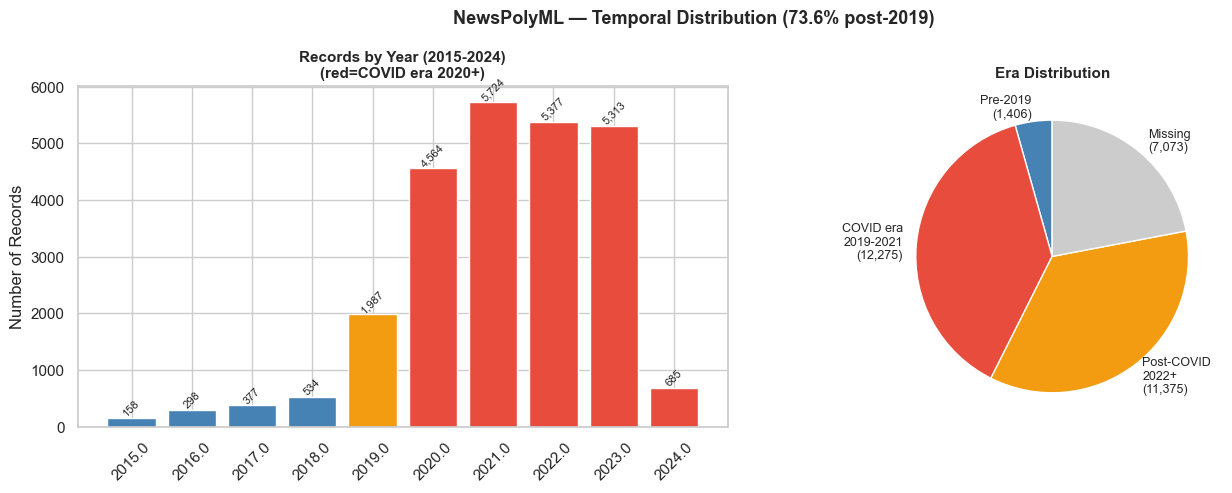

Fig 9 saved — newspolyml_temporal.png


In [13]:
year_counts = df['year'].value_counts().sort_index()
years_plot = year_counts[year_counts.index >= 2015]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_year = ['#e74c3c' if y >= 2020 else '#f39c12' if y >= 2019 else 'steelblue'
               for y in years_plot.index]
bars = axes[0].bar(years_plot.index.astype(str), years_plot.values,
                   color=colors_year, edgecolor='white')
for bar, val in zip(bars, years_plot.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{val:,}', ha='center', fontsize=8, rotation=45)
axes[0].set_title('Records by Year (2015-2024)\n(red=COVID era 2020+)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].tick_params(axis='x', rotation=45)

pre_covid = df[df['year'] < 2019]['year'].notna().sum()
covid = df[(df['year'] >= 2019) & (df['year'] < 2022)]['year'].notna().sum()
post_covid = df[df['year'] >= 2022]['year'].notna().sum()
missing = df['year'].isna().sum()
era_data = [pre_covid, covid, post_covid, missing]
era_labels = [f'Pre-2019\n({pre_covid:,})', f'COVID era\n2019-2021\n({covid:,})',
              f'Post-COVID\n2022+\n({post_covid:,})', f'Missing\n({missing:,})']
axes[1].pie(era_data, labels=era_labels, colors=['steelblue','#e74c3c','#f39c12','#cccccc'],
            startangle=90, textprops={'fontsize':9})
axes[1].set_title('Era Distribution', fontsize=11, fontweight='bold')

plt.suptitle('NewsPolyML — Temporal Distribution (73.6% post-2019)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_temporal.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 9 saved — newspolyml_temporal.png')

## 10. Italian Label Anomaly — Publisher-Driven

pagellapolitica (IT): false=16.7%, true=41.6%, mixture=41.1%
AFP: false=78.3%, true=3.3%, mixture=16.6%
Publisher rating scale drives label distribution, not actual disinformation rate.

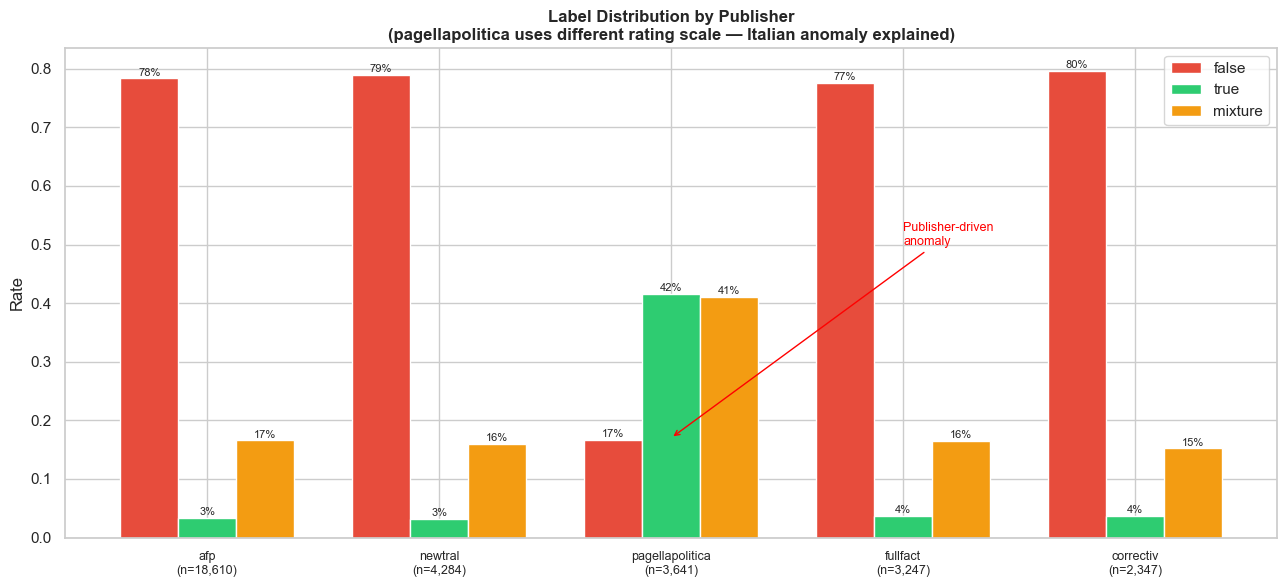

Fig 10 saved — newspolyml_publisher_label_bias.png


In [14]:
pub_label_data = {}
for pub in ['afp','newtral','pagellapolitica','fullfact','correctiv']:
    subset = df[df['article_publisher_name']==pub]
    pub_label_data[pub] = {
        'false': subset['normalized_label'].eq('false').mean(),
        'true': subset['normalized_label'].eq('true').mean(),
        'mixture': subset['normalized_label'].eq('mixture').mean(),
        'n': len(subset)
    }

pubs = list(pub_label_data.keys())
false_r = [pub_label_data[p]['false'] for p in pubs]
true_r = [pub_label_data[p]['true'] for p in pubs]
mix_r = [pub_label_data[p]['mixture'] for p in pubs]
x = np.arange(len(pubs)); width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x-width, false_r, width, color='#e74c3c', label='false', edgecolor='white')
bars2 = ax.bar(x, true_r, width, color='#2ecc71', label='true', edgecolor='white')
bars3 = ax.bar(x+width, mix_r, width, color='#f39c12', label='mixture', edgecolor='white')
for bar, val in zip(bars1, false_r):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=8)
for bar, val in zip(bars2, true_r):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=8)
for bar, val in zip(bars3, mix_r):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.0%}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'{p}\n(n={pub_label_data[p]["n"]:,})' for p in pubs], fontsize=9)
ax.set_title('Label Distribution by Publisher\n(pagellapolitica uses different rating scale — Italian anomaly explained)', fontsize=12, fontweight='bold')
ax.set_ylabel('Rate'); ax.legend()
ax.annotate('Publisher-driven\nanomaly', xy=(2, 0.17), xytext=(3, 0.5),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_publisher_label_bias.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 10 saved — newspolyml_publisher_label_bias.png')

## 11. Missing Values

claim_publication_date: 22.0% missing. article_description: 22.9% missing.
Core fields (normalized_label, article_language, article_body) complete.

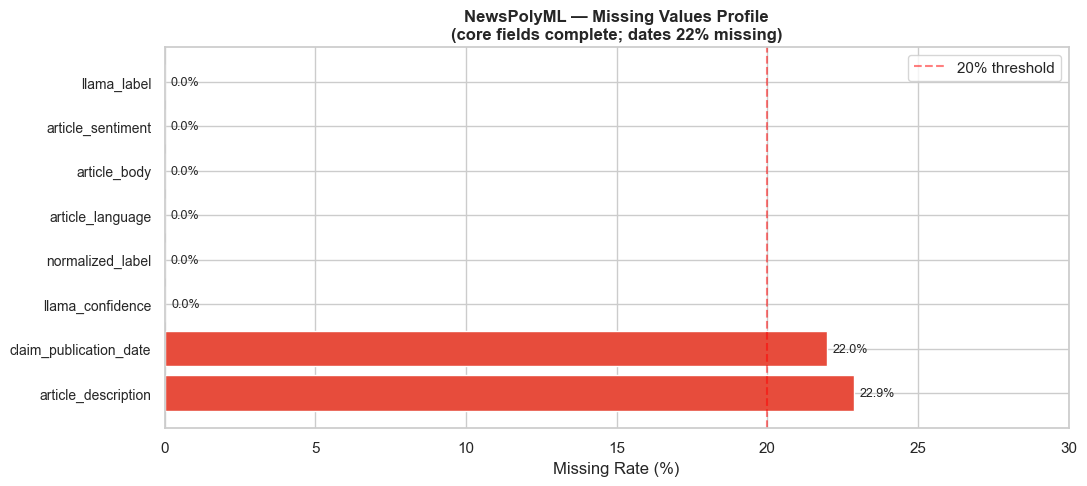

Fig 11 saved — newspolyml_missing_values.png


In [15]:
key_cols = ['normalized_label','article_language','article_body',
            'article_sentiment','llama_label','llama_confidence',
            'claim_publication_date','article_description']
null_rates = [(col, df[col].isnull().mean()*100) for col in key_cols]
null_rates.sort(key=lambda x: x[1], reverse=True)
cols, pcts = zip(*null_rates)
colors_miss = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#2ecc71' for p in pcts]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(cols)), pcts, color=colors_miss, edgecolor='white')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=10)
for i, (col, pct) in enumerate(zip(cols, pcts)):
    ax.text(pct+0.2, i, f'{pct:.1f}%', va='center', fontsize=9)
ax.axvline(20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
ax.set_title('NewsPolyML — Missing Values Profile\n(core fields complete; dates 22% missing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Missing Rate (%)'); ax.legend(); ax.set_xlim(0, 30)
plt.tight_layout()
plt.savefig('../figures/eda/newspolyml_missing_values.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 11 saved — newspolyml_missing_values.png')

## 12. Key Observations

**Total: 32,129 records** across 5 European languages (EN/ES/IT/DE/FR)
**false dominates: 71.4%** — severe class imbalance; HyDMIS needs weighted loss
**Italian anomaly:** pagellapolitica false=16.7% vs AFP false=78.3% — publisher rating scale drives label distribution
**LLaMA agreement: 65.4%** — 34.6% disagreement; LLaMA overestimates false, underestimates mixture
**LLaMA overconfident:** 83.6% confidence=5 but 34.6% wrong — high confidence ≠ high accuracy
**93.9% negative sentiment** — fact-check debunking articles universally negative framing
**French longest articles:** mean=6,718 chars vs English 3,275 chars — 2x length variation
**73.6% post-2019** — COVID-era disinformation surge dominates dataset
**HyDMIS uses NewsPolyML** as European multilingual evaluation benchmark — tests cross-lingual generalization